In [12]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [13]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

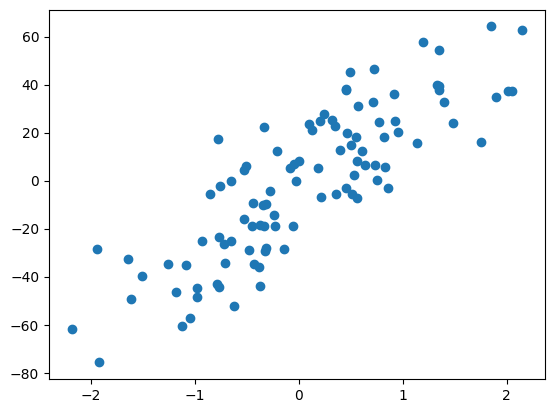

In [14]:
plt.scatter(x,y)

In [15]:
from sklearn.linear_model import LinearRegression,Ridge

In [16]:
lr=LinearRegression()
lr.fit(x,y)
print(lr.coef_,lr.intercept_)

[27.82809103] -2.29474455867698


In [17]:
rr1=Ridge(alpha=10)
rr1.fit(x,y)
print(rr1.coef_,rr1.intercept_)

[24.9546267] -2.1269130035235735


In [18]:
rr=Ridge(alpha=100)
rr.fit(x,y)
print(rr.coef_,rr.intercept_)

[12.93442104] -1.4248441496033308


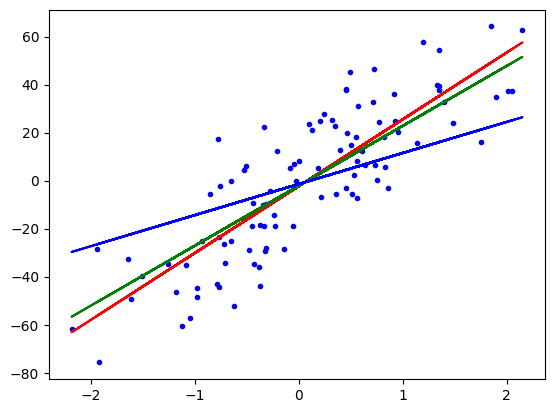

In [19]:
plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),color='r',label='alpha=0')
plt.plot(x,rr1.predict(x),color='g',label='alpha=10')
plt.plot(x,rr.predict(x),color='b',label='alpha=100')

In [44]:
class MeraRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.m=None
        self.b=None
        
    def fit(self,x_train,y_train):
        num=0
        den=0
        
        for i in range(x_train.shape[0]):
            num=num+((y_train[i] - y_train.mean())*(x_train[i] - x_train.mean()))
            den=den+(x_train[i] - x_train.mean())*(x_train[i] - x_train.mean())
        
        self.m=num/(den+self.alpha)
        self.b=y_train.mean()-(self.m*x_train.mean())
        print(self.m,self.b)
        
    def predict(self,x_test):
        pass

In [48]:
reg=MeraRidge(alpha=10)
reg.fit(x,y)

[24.9546267] [-2.126913]


In [49]:
reg=MeraRidge(alpha=100)
reg.fit(x,y)

[12.93442104] [-1.42484415]


                        For Multiple Regression

In [54]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np
from sklearn.model_selection import train_test_split

In [55]:
x,y=load_diabetes(return_X_y=True)

In [59]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)

In [60]:
reg=Ridge(alpha=0.1,solver='cholesky')

In [61]:
reg.fit(x_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [62]:
y_pred=reg.predict(x_test)
r2_score(y_test,y_pred)

0.4693128853309805

In [63]:
print(reg.coef_,reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681] 150.89053425602808


In [65]:
np.insert(x_train,0,1,axis=1)

array([[ 1.        ,  0.0090156 , -0.04464164, ...,  0.02323852,
         0.05568623,  0.10661708],
       [ 1.        ,  0.03081083,  0.05068012, ...,  0.05755657,
         0.0354587 ,  0.08590655],
       [ 1.        ,  0.01628068, -0.04464164, ..., -0.03949338,
        -0.05947118, -0.06735141],
       ...,
       [ 1.        ,  0.04170844,  0.05068012, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [ 1.        ,  0.01628068,  0.05068012, ..., -0.03949338,
         0.01703607,  0.00720652],
       [ 1.        ,  0.04897352,  0.05068012, ...,  0.07120998,
         0.03243232,  0.04862759]])

In [70]:
class MultiRidge:
    def __init__(self,alpha=0.1):
        self.aplha=alpha
        self.coef_=None
        self.intercept_=None
        
        
    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)
        I=np.identity(x_train.shape[1])
        I[0][0]=0
        result=np.linalg.inv(np.dot(x_train.T,x_train)+self.alpha*I).dot(x_train.T).dot(y_train)
        self.intercept_=result[0]
        self.coef_=result[1:]
    def predict(self,x_test):
        return np.dot(x_test,self.coef_)+self.intercept_

In [71]:
mreg=MultiRidge()
reg.fit(x_train,y_train)
y_pred=reg.predict(x_test)
print(r2_score(y_test,y_pred))
print(reg.coef_,reg.intercept_)

0.4693128853309805
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681] 150.89053425602808
